In [1]:
from utils import *
from imports import *
from configs import load_config
from pipelines import InferencePipeline
from os import environ

Sort GPU memory cache stuff

In [2]:
# Clear any previous GPU usage
torch.cuda.empty_cache()

# Set environment variable for better memory management
environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments: True"

print("GPU cache cleared")

GPU cache cleared


Load config and setup

In [3]:
config = load_config(path="../configs/default.yaml")
checkpoint_path = "../runs/20260222-130917/best_model.pth"

Load model

In [4]:
inference_pipeline = InferencePipeline(config=config)
inference_pipeline.load_model(checkpoint_path=checkpoint_path)


LOADING MODEL FOR INFERENCE
Using device: cuda
Loaded model from ..\runs\20260222-130917\best_model.pth
Epoch: 20
Best val loss: 0.0006
    Model loaded from: ..\runs\20260222-130917\best_model.pth
    Using device: cuda


D:\anaconda3\envs\Image_Denoising\Lib\site-packages\torch\_utils.py:102: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  untyped_storage = torch.UntypedStorage(self.size(), device=device)


Check GPU memory

In [5]:
print(f"GPU allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

if torch.cuda.memory_allocated() / 1024**3 > 6.0:
    print("GPU memory tight, moving to CPU")
    inference_pipeline.model = inference_pipeline.model.cpu()
    inference_pipeline.device = torch.device("cpu")

GPU allocated: 0.03 GB
GPU reserved: 0.13 GB


Denoise saved inference images

In [6]:
inference_pipeline.run_inference_workflow(num_examples=5)


RUNNING INFERENCE
Denoising 8 images...
Large image (4208x3120, 13.1MP) - using tiled processing
Processing 4208x3120 image in 512x512 tiles (overlap=64)...)


Processing tiles: 100%|██████████| 70/70 [00:02<00:00, 34.53it/s]


Processed 70 tiles successfully
Large image (5328x3000, 16.0MP) - using tiled processing
Processing 5328x3000 image in 512x512 tiles (overlap=64)...)


Processing tiles: 100%|██████████| 84/84 [00:01<00:00, 42.33it/s]


Processed 84 tiles successfully
Large image (4032x3024, 12.2MP) - using tiled processing
Processing 4032x3024 image in 512x512 tiles (overlap=64)...)


...

Processed 63 tiles successfully
Large image (5328x3000, 16.0MP) - using tiled processing
Processing 5328x3000 image in 512x512 tiles (overlap=64)...)


Processing tiles: 100%|██████████| 84/84 [00:01<00:00, 43.51it/s]


Processed 84 tiles successfully
Large image (4048x3044, 12.3MP) - using tiled processing
Processing 4048x3044 image in 512x512 tiles (overlap=64)...)


Processing tiles: 70it [00:01, 42.07it/s]                        


Processed 63 tiles successfully

Denoised 8 images
Saved to ..\runs\20260222-130917\inference_results

SAVING 5 EXAMPLE COMPARISONS
Saving 5 example denoising comparisons...
Saved comparison to ..\runs\20260222-130917\figures\examples\example_0.png
Saved comparison to ..\runs\20260222-130917\figures\examples\example_1.png
Saved comparison to ..\runs\20260222-130917\figures\examples\example_2.png
Saved comparison to ..\runs\20260222-130917\figures\examples\example_3.png
Saved comparison to ..\runs\20260222-130917\figures\examples\example_4.png
Saved 5 examples to ..\runs\20260222-130917\figures\examples


Show visual comparisons

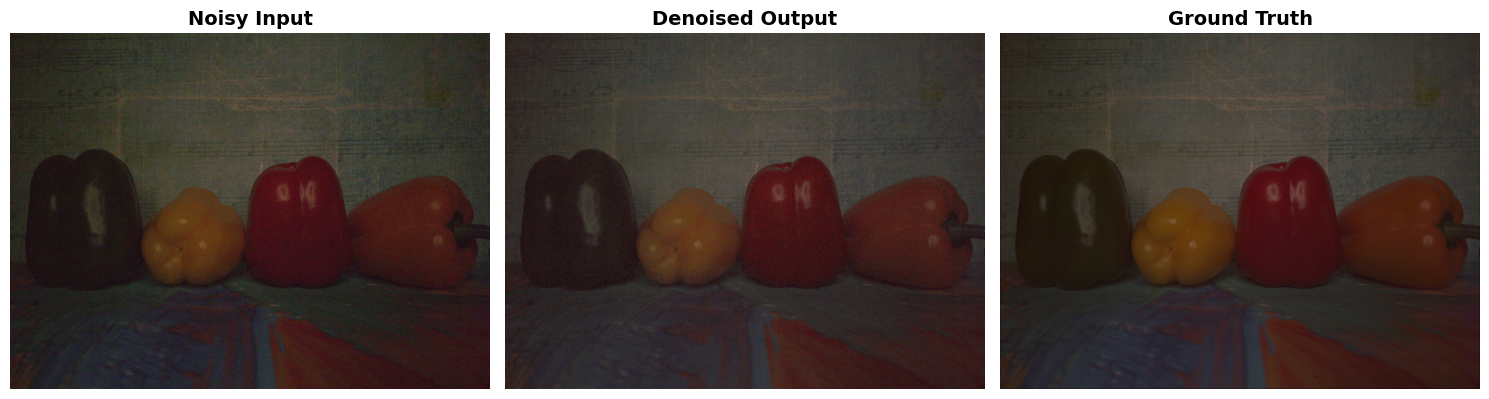

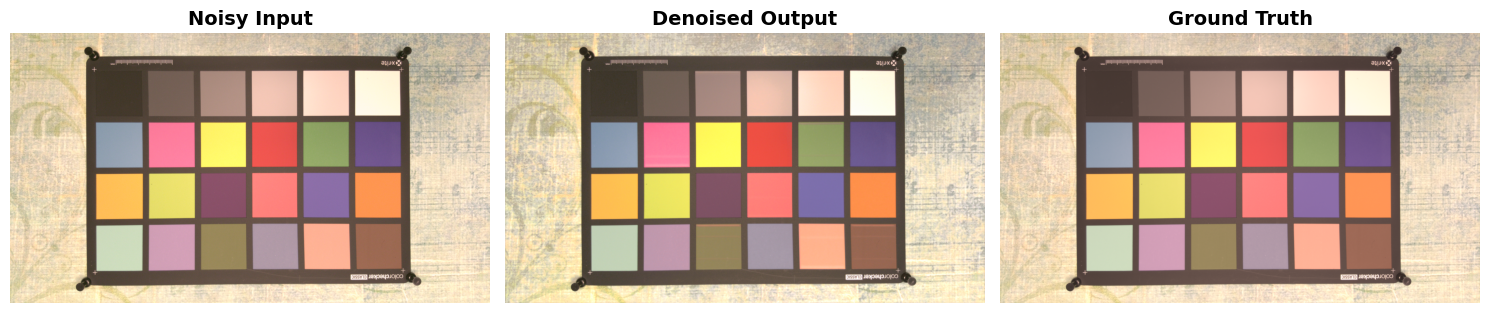

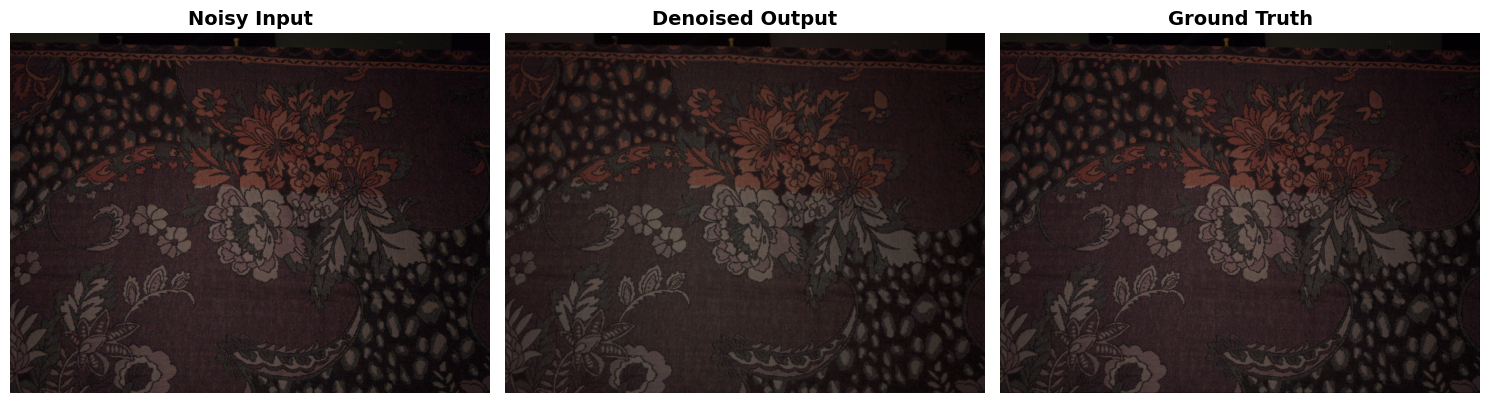

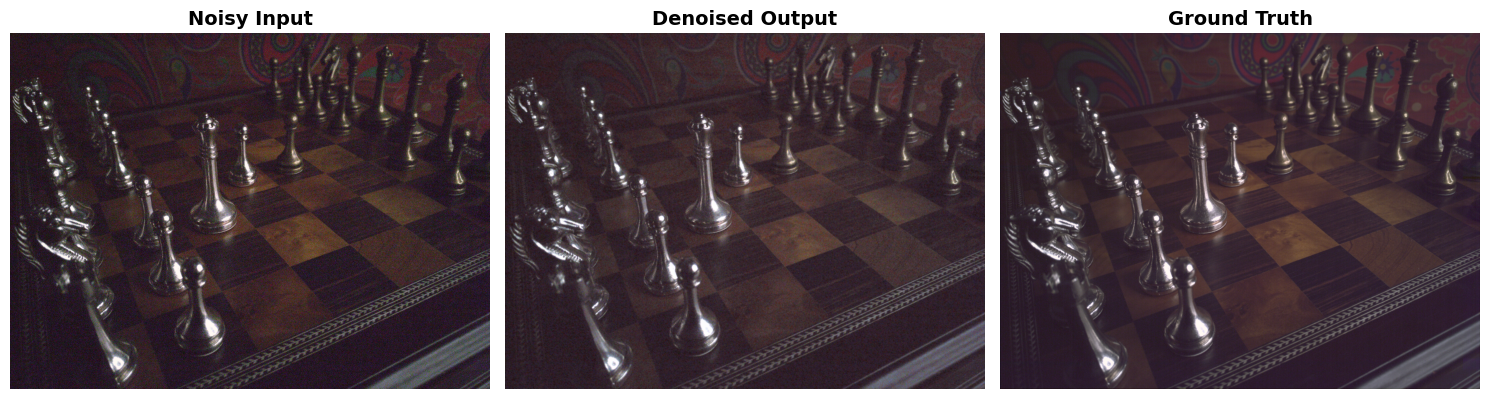

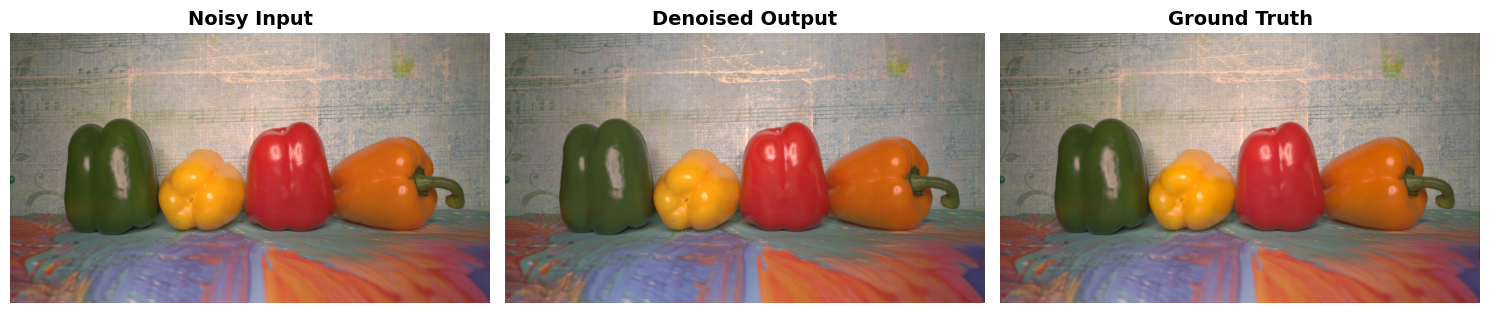

In [7]:
for i in range(5):
    show_denoising_comparison(
        noisy_path=f"{config.paths.inference_dir}/inf_noisy_{i}.png",
        denoised_path=f"{inference_pipeline.inference_results_dir}/denoised_{i}.png",
        gt_path=f"{config.paths.inference_dir}/inf_gt_{i}.png"
    )

Interactive demo - upload your own image

In [ ]:
uploaded_image_path = "path/to/uploaded/noisy_image.png"
output_path = "denoised_uploaded.png"

inference_pipeline.denoise_single_image(
    image_path=uploaded_image_path,
    output_path=output_path
)

# Show result
show_denoising_comparison(
    noisy_path=uploaded_image_path,
    denoised_path=output_path
)

Batch inference example

In [ ]:
inference_pipeline.denoise_directory(
    input_dir="examples/noisy_images",
    output_dir="examples/denoised_images"
)

Performance analysis

In [ ]:
import time
start = time.time()
for i in range(10):
    inference_pipeline.denoise_single_image(
        image_path="",
        output_path=""
    )
    avg_time = (time.time() - start) / 10
    print(f"Average inference time: {avg_time*1000:.1f} ms")